In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import glob
from pathlib import Path
import random

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split

data_path = r"DL_PA2\processed_data\quickdraw_train.npz"
data = np.load(data_path)

print("Keys in the npz file:", data.files)

for key in data.files:
    print(f"{key}: shape = {data[key].shape}, dtype = {data[key].dtype}")

Keys in the npz file: ['x_train', 'y_train', 'class_names']
x_train: shape = (60000, 784), dtype = uint8
y_train: shape = (60000,), dtype = int64
class_names: shape = (15,), dtype = <U11


In [3]:
train_data = np.load(r"DL_PA2\processed_data\quickdraw_train.npz")
test_data = np.load(r"DL_PA2\processed_data\quickdraw_test.npz")

X_train = train_data['x_train']
y_train = train_data['y_train']
class_names = train_data['class_names']
X_test = test_data['test_images']

X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Classes: {class_names}")
print(f"Pixel range: [{X_train.min():.1f}, {X_train.max():.1f}]")

Training samples: 60000
Test samples: 15000
Classes: ['apple' 'baseballbat' 'basketball' 'clock' 'compass' 'cookie' 'donut'
 'ladder' 'mountain' 'pizza' 'rabbit' 'soccerball' 'spider' 't-shirt'
 'wheel']
Pixel range: [0.0, 1.0]


In [ ]:
import torchvision.transforms as T

class QuickDrawDataset(Dataset):
    def __init__(self, images, labels, augment=False):
        self.images = images
        self.labels = labels
        self.augment = augment
        self.transform = T.Compose([
            T.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.85, 1.15)),
            T.RandomErasing(p=0.2, scale=(0.02, 0.1)),
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.augment:
            image = torch.tensor(image.reshape(1, 28, 28), dtype=torch.float32)
            image = self.transform(image)
            image = image.reshape(-1)
        else:
            image = torch.tensor(image.reshape(-1), dtype=torch.float32)

        label = torch.tensor(label, dtype=torch.long)
        return image, label

In [ ]:
train_aug_dataset = QuickDrawDataset(X_train, y_train, augment=True)
val_clean_dataset = QuickDrawDataset(X_train, y_train, augment=False)

total_samples = len(train_aug_dataset)
train_size = int(0.8 * total_samples)
val_size = total_samples - train_size

generator = torch.Generator().manual_seed(42)
train_indices, val_indices = random_split(range(total_samples), [train_size, val_size], generator=generator)

from torch.utils.data import Subset
train_dataset = Subset(train_aug_dataset, train_indices.indices)
val_dataset = Subset(val_clean_dataset, val_indices.indices)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

print(f"Training samples: {len(train_dataset)} (with augmentation)")
print(f"Validation samples: {len(val_dataset)} (no augmentation)")

Training samples: 48000 (with augmentation)
Validation samples: 12000 (no augmentation)


In [ ]:
print(f"X_train range: [{X_train.min():.1f}, {X_train.max():.1f}]")
print(f"X_test range: [{X_test.min():.1f}, {X_test.max():.1f}]")

X_train range: [0.0, 1.0]
X_test range: [0.0, 1.0]


Using device: cuda
Total parameters: 1,339,407
Epoch 1/40 | Train Acc: 50.09% | Val Acc: 66.09% | LR: 0.000998
Epoch 2/40 | Train Acc: 58.42% | Val Acc: 69.28% | LR: 0.000994
Epoch 3/40 | Train Acc: 61.29% | Val Acc: 71.92% | LR: 0.000986
Epoch 4/40 | Train Acc: 63.28% | Val Acc: 73.17% | LR: 0.000976
Epoch 5/40 | Train Acc: 64.24% | Val Acc: 74.55% | LR: 0.000962
Epoch 6/40 | Train Acc: 65.47% | Val Acc: 75.23% | LR: 0.000946
Epoch 7/40 | Train Acc: 66.51% | Val Acc: 74.98% | LR: 0.000926
Epoch 8/40 | Train Acc: 67.16% | Val Acc: 76.65% | LR: 0.000905
Epoch 9/40 | Train Acc: 68.11% | Val Acc: 77.46% | LR: 0.000880
Epoch 10/40 | Train Acc: 68.36% | Val Acc: 77.23% | LR: 0.000854
Epoch 11/40 | Train Acc: 69.18% | Val Acc: 77.55% | LR: 0.000825
Epoch 12/40 | Train Acc: 69.47% | Val Acc: 78.12% | LR: 0.000794
Epoch 13/40 | Train Acc: 69.93% | Val Acc: 78.73% | LR: 0.000761
Epoch 14/40 | Train Acc: 70.28% | Val Acc: 78.96% | LR: 0.000727
Epoch 15/40 | Train Acc: 70.79% | Val Acc: 80.00% | 

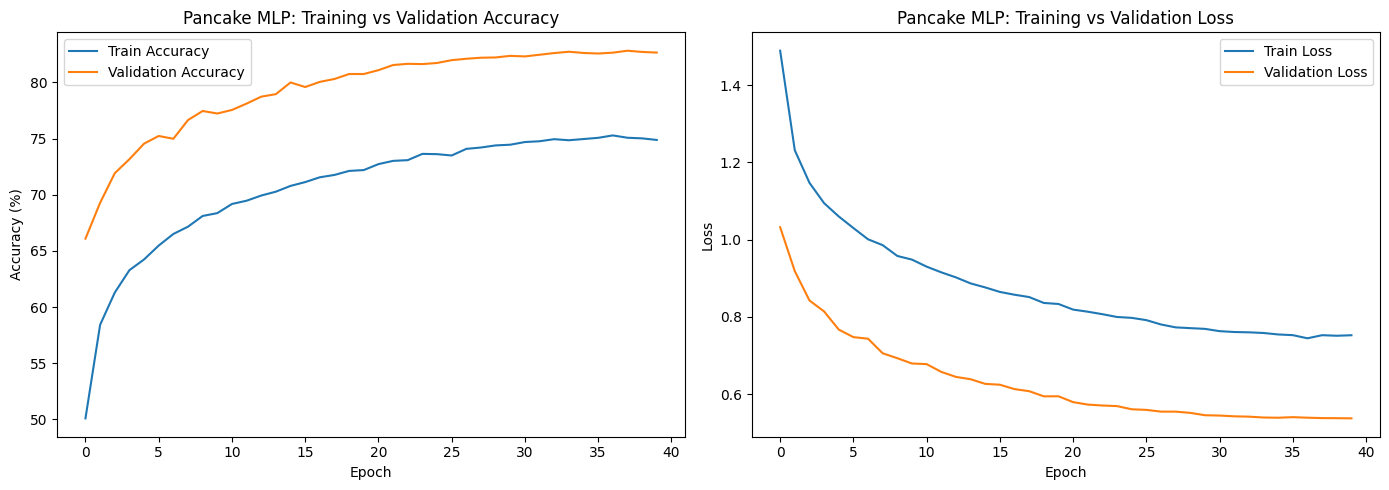

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

class MLP_Pancake(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(MLP_Pancake, self).__init__()
        self.fc1 = nn.Linear(input_size, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.fc3 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(-1, 784)

        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_pancake = MLP_Pancake().to(device)
param_count = sum(p.numel() for p in model_pancake.parameters())
print(f"Using device: {device}")
print(f"Total parameters: {param_count:,}")

criterion_a = nn.CrossEntropyLoss()
optimizer_a = optim.AdamW(model_pancake.parameters(), lr=0.001, weight_decay=1e-4)
epochs = 40
scheduler_a = optim.lr_scheduler.CosineAnnealingLR(optimizer_a, T_max=epochs, eta_min=1e-6)

train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(epochs):
    model_pancake.train()
    correct, total, train_loss = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_a.zero_grad()
        outputs = model_pancake(images)
        loss = criterion_a(outputs, labels)
        loss.backward()
        optimizer_a.step()

        train_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    train_losses.append(train_loss / total)
    train_accs.append(100 * correct / total)

    model_pancake.eval()
    val_correct, val_total, val_running_loss = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_pancake(images)
            loss = criterion_a(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            val_correct += preds.eq(labels).sum().item()
            val_total += labels.size(0)

    val_losses.append(val_running_loss / val_total)
    val_accs.append(100 * val_correct / val_total)

    scheduler_a.step()

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_accs[-1]:.2f}% | Val Acc: {val_accs[-1]:.2f}% | LR: {scheduler_a.get_last_lr()[0]:.6f}")

history_a = {'train_accs': train_accs, 'val_accs': val_accs, 'train_losses': train_losses, 'val_losses': val_losses}
print(f"\nFinal Validation Accuracy: {val_accs[-1]:.2f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_accs, label='Train Accuracy')
ax1.plot(val_accs, label='Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Pancake MLP: Training vs Validation Accuracy')
ax1.legend()

ax2.plot(train_losses, label='Train Loss')
ax2.plot(val_losses, label='Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Pancake MLP: Training vs Validation Loss')
ax2.legend()

plt.tight_layout()
plt.show()

## Part B: The Tower (Depth Focus)
- Deep MLP: 5+ hidden layers, 128/256 neurons each.
- Hierarchical feature learning: lines → shapes → objects.
- Use BatchNorm to help training (avoid vanishing gradients).
- No residual connections yet.

Below is a code cell for a deep, narrow MLP with BatchNorm.

In [ ]:
print(f"Using device: {device}")

Using device: cuda


Total parameters (Tower): 253583
Epoch 1/40 | Train Acc: 29.73% | Val Acc: 51.31%
Epoch 2/40 | Train Acc: 42.48% | Val Acc: 57.03%
Epoch 3/40 | Train Acc: 47.16% | Val Acc: 59.34%
Epoch 4/40 | Train Acc: 50.16% | Val Acc: 64.16%
Epoch 5/40 | Train Acc: 52.65% | Val Acc: 66.90%
Epoch 6/40 | Train Acc: 54.00% | Val Acc: 66.88%
Epoch 7/40 | Train Acc: 55.24% | Val Acc: 68.18%
Epoch 8/40 | Train Acc: 56.57% | Val Acc: 68.40%
Epoch 9/40 | Train Acc: 57.26% | Val Acc: 69.42%
Epoch 10/40 | Train Acc: 58.21% | Val Acc: 70.19%
Epoch 11/40 | Train Acc: 58.50% | Val Acc: 70.47%
Epoch 12/40 | Train Acc: 59.58% | Val Acc: 70.82%
Epoch 13/40 | Train Acc: 59.73% | Val Acc: 71.44%
Epoch 14/40 | Train Acc: 60.38% | Val Acc: 71.52%
Epoch 15/40 | Train Acc: 60.80% | Val Acc: 71.97%
Epoch 16/40 | Train Acc: 61.10% | Val Acc: 71.63%
Epoch 17/40 | Train Acc: 61.26% | Val Acc: 72.57%
Epoch 18/40 | Train Acc: 61.56% | Val Acc: 71.86%
Epoch 19/40 | Train Acc: 62.03% | Val Acc: 73.09%
Epoch 20/40 | Train Acc: 6

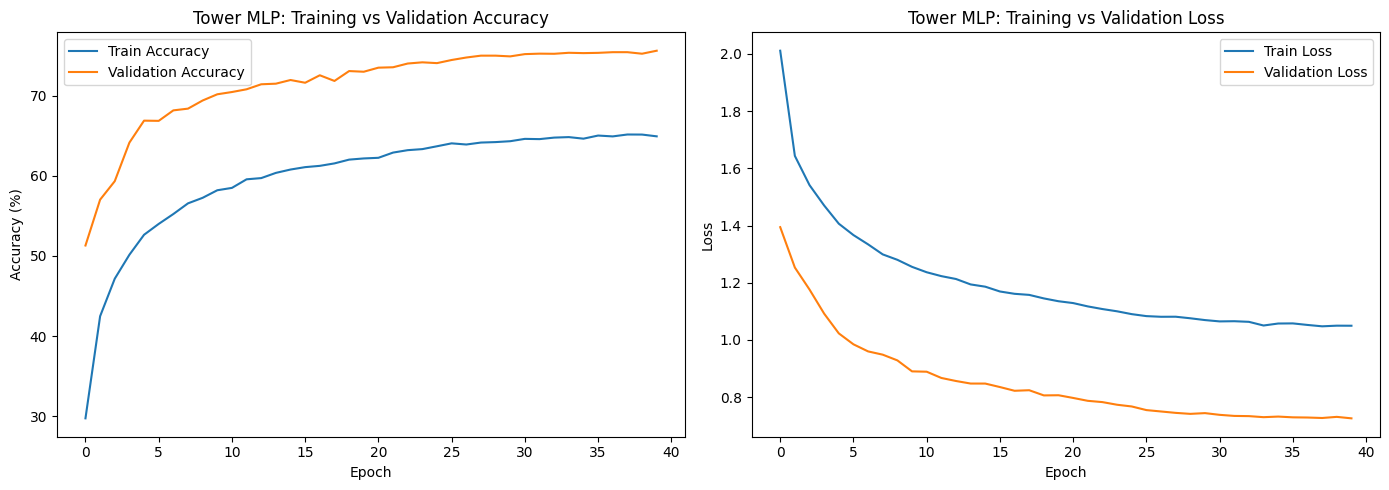

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP_Tower(nn.Module):
    def __init__(self, input_size=784, num_classes=15, hidden_size=128, dropout=0.2):
        super(MLP_Tower, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, hidden_size)
        self.fc5 = nn.Linear(hidden_size, hidden_size)
        self.fc6 = nn.Linear(hidden_size, hidden_size)
        self.fc7 = nn.Linear(hidden_size, hidden_size)
        self.fc8 = nn.Linear(hidden_size, hidden_size)
        self.fc9 = nn.Linear(hidden_size, hidden_size)
        self.fc10 = nn.Linear(hidden_size, hidden_size)
        self.fc_out = nn.Linear(hidden_size, num_classes)

        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        self.bn3 = nn.BatchNorm1d(hidden_size)
        self.bn4 = nn.BatchNorm1d(hidden_size)
        self.bn5 = nn.BatchNorm1d(hidden_size)
        self.bn6 = nn.BatchNorm1d(hidden_size)
        self.bn7 = nn.BatchNorm1d(hidden_size)
        self.bn8 = nn.BatchNorm1d(hidden_size)
        self.bn9 = nn.BatchNorm1d(hidden_size)
        self.bn10 = nn.BatchNorm1d(hidden_size)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = x.view(-1, 784)

        x = self.fc1(x)
        x = self.bn1(x)
        x = F.gelu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.gelu(x)
        x = self.dropout(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = F.gelu(x)
        x = self.dropout(x)

        x = self.fc4(x)
        x = self.bn4(x)
        x = F.gelu(x)
        x = self.dropout(x)

        x = self.fc5(x)
        x = self.bn5(x)
        x = F.gelu(x)
        x = self.dropout(x)

        x = self.fc6(x)
        x = self.bn6(x)
        x = F.gelu(x)
        x = self.dropout(x)

        x = self.fc7(x)
        x = self.bn7(x)
        x = F.gelu(x)
        x = self.dropout(x)

        x = self.fc8(x)
        x = self.bn8(x)
        x = F.gelu(x)
        x = self.dropout(x)

        x = self.fc9(x)
        x = self.bn9(x)
        x = F.gelu(x)
        x = self.dropout(x)

        x = self.fc10(x)
        x = self.bn10(x)
        x = F.gelu(x)
        x = self.dropout(x)

        x = self.fc_out(x)
        return x

model_tower = MLP_Tower().to(device)
print(f"Total parameters (Tower): {sum(p.numel() for p in model_tower.parameters())}")

criterion_b = nn.CrossEntropyLoss()
optimizer_b = torch.optim.Adam(model_tower.parameters(), lr=0.001, weight_decay=1e-4)
epochs = 40
scheduler_b = optim.lr_scheduler.CosineAnnealingLR(optimizer_b, T_max=epochs, eta_min=1e-6)

train_losses, val_losses, train_accs, val_accs = [], [], [], []
for epoch in range(epochs):
    model_tower.train()
    correct, total, train_loss = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_b.zero_grad()
        outputs = model_tower(images)
        loss = criterion_b(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model_tower.parameters(), max_norm=1.0)
        optimizer_b.step()
        train_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
    train_losses.append(train_loss / total)
    train_accs.append(100 * correct / total)

    model_tower.eval()
    correct, total, val_loss = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_tower(images)
            loss = criterion_b(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
    val_losses.append(val_loss / total)
    val_accs.append(100 * correct / total)
    scheduler_b.step()
    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_accs[-1]:.2f}% | Val Acc: {val_accs[-1]:.2f}%")

history_b = {'train_accs': train_accs, 'val_accs': val_accs, 'train_losses': train_losses, 'val_losses': val_losses}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_accs, label='Train Accuracy')
ax1.plot(val_accs, label='Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Tower MLP: Training vs Validation Accuracy')
ax1.legend()

ax2.plot(train_losses, label='Train Loss')
ax2.plot(val_losses, label='Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Tower MLP: Training vs Validation Loss')
ax2.legend()

plt.tight_layout()
plt.show()

part c champion model


Using device: cuda
Total parameters: 783,823
Epoch 01/40 | Train Acc: 44.78% | Val Acc: 63.68% | LR: 0.000998
Epoch 02/40 | Train Acc: 56.75% | Val Acc: 69.47% | LR: 0.000994
Epoch 03/40 | Train Acc: 60.16% | Val Acc: 70.46% | LR: 0.000986
Epoch 04/40 | Train Acc: 62.33% | Val Acc: 71.86% | LR: 0.000976
Epoch 05/40 | Train Acc: 63.88% | Val Acc: 72.43% | LR: 0.000962
Epoch 06/40 | Train Acc: 65.56% | Val Acc: 73.49% | LR: 0.000946
Epoch 07/40 | Train Acc: 66.38% | Val Acc: 75.59% | LR: 0.000926
Epoch 08/40 | Train Acc: 67.16% | Val Acc: 75.92% | LR: 0.000905
Epoch 09/40 | Train Acc: 68.03% | Val Acc: 76.68% | LR: 0.000880
Epoch 10/40 | Train Acc: 68.62% | Val Acc: 77.09% | LR: 0.000854
Epoch 11/40 | Train Acc: 69.24% | Val Acc: 77.74% | LR: 0.000825
Epoch 12/40 | Train Acc: 69.77% | Val Acc: 78.18% | LR: 0.000794
Epoch 13/40 | Train Acc: 70.44% | Val Acc: 78.64% | LR: 0.000761
Epoch 14/40 | Train Acc: 70.96% | Val Acc: 78.99% | LR: 0.000727
Epoch 15/40 | Train Acc: 71.48% | Val Acc: 79

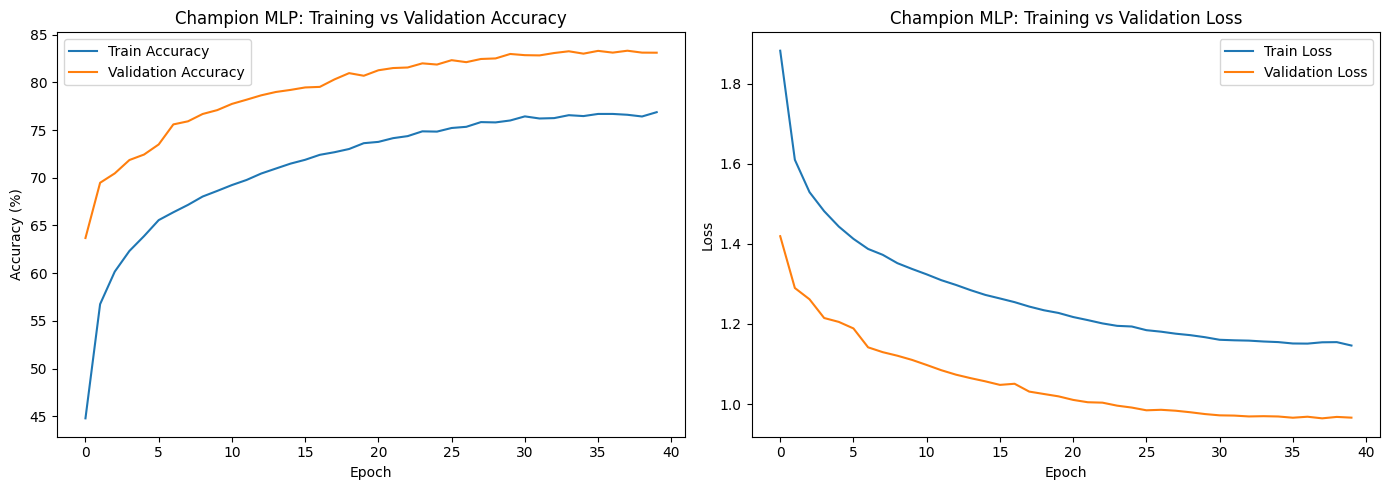

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

class ChampionMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(ChampionMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 384)
        self.bn2 = nn.BatchNorm1d(384)
        self.fc3 = nn.Linear(384, 256)
        self.bn3 = nn.BatchNorm1d(256)
        self.fc4 = nn.Linear(256, 192)
        self.bn4 = nn.BatchNorm1d(192)
        self.fc5 = nn.Linear(192, 128)
        self.bn5 = nn.BatchNorm1d(128)
        self.fc6 = nn.Linear(128, 64)
        self.bn6 = nn.BatchNorm1d(64)
        self.fc_out = nn.Linear(64, num_classes)

        self.dropout1 = nn.Dropout(0.1)
        self.dropout2 = nn.Dropout(0.2)
        self.dropout3 = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(-1, 784)

        x = self.fc1(x)
        x = self.bn1(x)
        x = F.gelu(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.gelu(x)
        x = self.dropout1(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = F.gelu(x)
        x = self.dropout2(x)

        x = self.fc4(x)
        x = self.bn4(x)
        x = F.gelu(x)
        x = self.dropout2(x)

        x = self.fc5(x)
        x = self.bn5(x)
        x = F.gelu(x)
        x = self.dropout3(x)

        x = self.fc6(x)
        x = self.bn6(x)
        x = F.gelu(x)
        x = self.dropout3(x)

        x = self.fc_out(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ChampionMLP().to(device)
param_count = sum(p.numel() for p in model.parameters())
print(f"Using device: {device}")
print(f"Total parameters: {param_count:,}")

criterion_c = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_c = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)
epochs = 40
scheduler_c = optim.lr_scheduler.CosineAnnealingLR(optimizer_c, T_max=epochs, eta_min=1e-6)

train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_acc = 0

for epoch in range(epochs):
    model.train()
    correct, total, train_loss = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_c.zero_grad()
        outputs = model(images)
        loss = criterion_c(outputs, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer_c.step()

        train_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    train_losses.append(train_loss / total)
    train_accs.append(100 * correct / total)

    model.eval()
    val_correct, val_total, val_running_loss = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion_c(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            val_correct += preds.eq(labels).sum().item()
            val_total += labels.size(0)

    val_losses.append(val_running_loss / val_total)
    val_accs.append(100 * val_correct / val_total)

    scheduler_c.step()

    if val_accs[-1] > best_val_acc:
        best_val_acc = val_accs[-1]
        torch.save(model.state_dict(), 'champion_best.pth')

    print(f"Epoch {epoch+1:02d}/{epochs} | Train Acc: {train_accs[-1]:.2f}% | Val Acc: {val_accs[-1]:.2f}% | LR: {scheduler_c.get_last_lr()[0]:.6f}")

history_c = {'train_accs': train_accs, 'val_accs': val_accs, 'train_losses': train_losses, 'val_losses': val_losses}
print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_accs, label='Train Accuracy')
ax1.plot(val_accs, label='Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Champion MLP: Training vs Validation Accuracy')
ax1.legend()

ax2.plot(train_losses, label='Train Loss')
ax2.plot(val_losses, label='Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Champion MLP: Training vs Validation Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
model.load_state_dict(torch.load('champion_best.pth'))
model.eval()

X_test_tensor = torch.tensor(X_test.reshape(-1, 784), dtype=torch.float32)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

all_preds = []
with torch.no_grad():
    for (images,) in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())

import pandas as pd
submission = pd.DataFrame({
    'id': range(len(all_preds)),
    'label': all_preds
})
submission.to_csv('submission.csv', index=False)
print(f"Saved {len(all_preds)} predictions to submission.csv")

paste_ready = ",".join(map(str, all_preds))
print(f"\n--- PASTE THIS INTO THE LEADERBOARD PORTAL ---")
print(paste_ready)
print(f"--- END ({len(all_preds)} predictions) ---")

C:\Users\azama\AppData\Local\Temp\ipykernel_23660\1268580010.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('champion_best.pth'))


Saved 15000 predictions to submission.csv

--- PASTE THIS INTO THE LEADERBOARD PORTAL ---
6,11,5,4,0,1,11,9,14,8,9,7,11,11,13,8,13,12,11,5,13,6,14,8,0,13,13,2,6,5,14,11,1,12,13,5,11,5,8,2,12,8,0,2,13,1,6,14,10,1,5,11,0,9,5,11,6,6,10,9,9,6,7,2,0,12,11,12,3,11,4,6,3,14,0,6,5,6,2,11,10,13,6,4,12,0,0,2,14,11,0,7,1,11,5,3,3,12,9,10,11,12,1,4,5,9,7,4,14,11,9,1,1,13,12,2,1,7,9,0,4,7,9,2,13,13,7,14,3,4,5,6,0,8,11,11,11,12,12,13,10,11,1,14,1,12,7,11,3,0,4,14,1,12,6,8,0,4,9,6,0,9,5,13,9,13,5,6,1,5,12,10,4,4,13,7,14,6,7,11,2,13,10,3,12,3,8,6,2,1,14,14,8,6,0,4,1,5,5,10,5,14,10,1,13,1,1,10,5,7,14,11,1,9,6,2,6,3,8,1,1,4,7,9,9,6,13,14,3,0,12,6,4,14,1,3,10,0,11,4,9,11,4,12,4,9,5,0,6,7,6,5,7,1,13,5,1,9,0,4,13,0,7,4,6,3,12,12,3,7,13,11,11,3,10,7,12,8,6,6,1,7,12,12,0,3,14,4,12,3,6,6,2,0,9,12,9,6,3,8,5,12,3,0,6,11,11,7,13,8,12,13,11,1,5,3,9,10,14,13,0,9,12,11,7,9,3,10,11,12,13,12,6,3,2,14,7,8,10,1,11,10,11,1,10,14,12,14,0,7,7,0,11,7,3,7,12,1,7,12,11,13,4,11,5,14,11,8,7,11,12,2,4,13,1,2,4,10,0,13,9,3,10,9,

## Part D: Theoretical Analysis
### Confusion Matrix & Top Confused Pairs

C:\Users\azama\AppData\Local\Temp\ipykernel_23660\2131121360.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('champion_best.pth'))


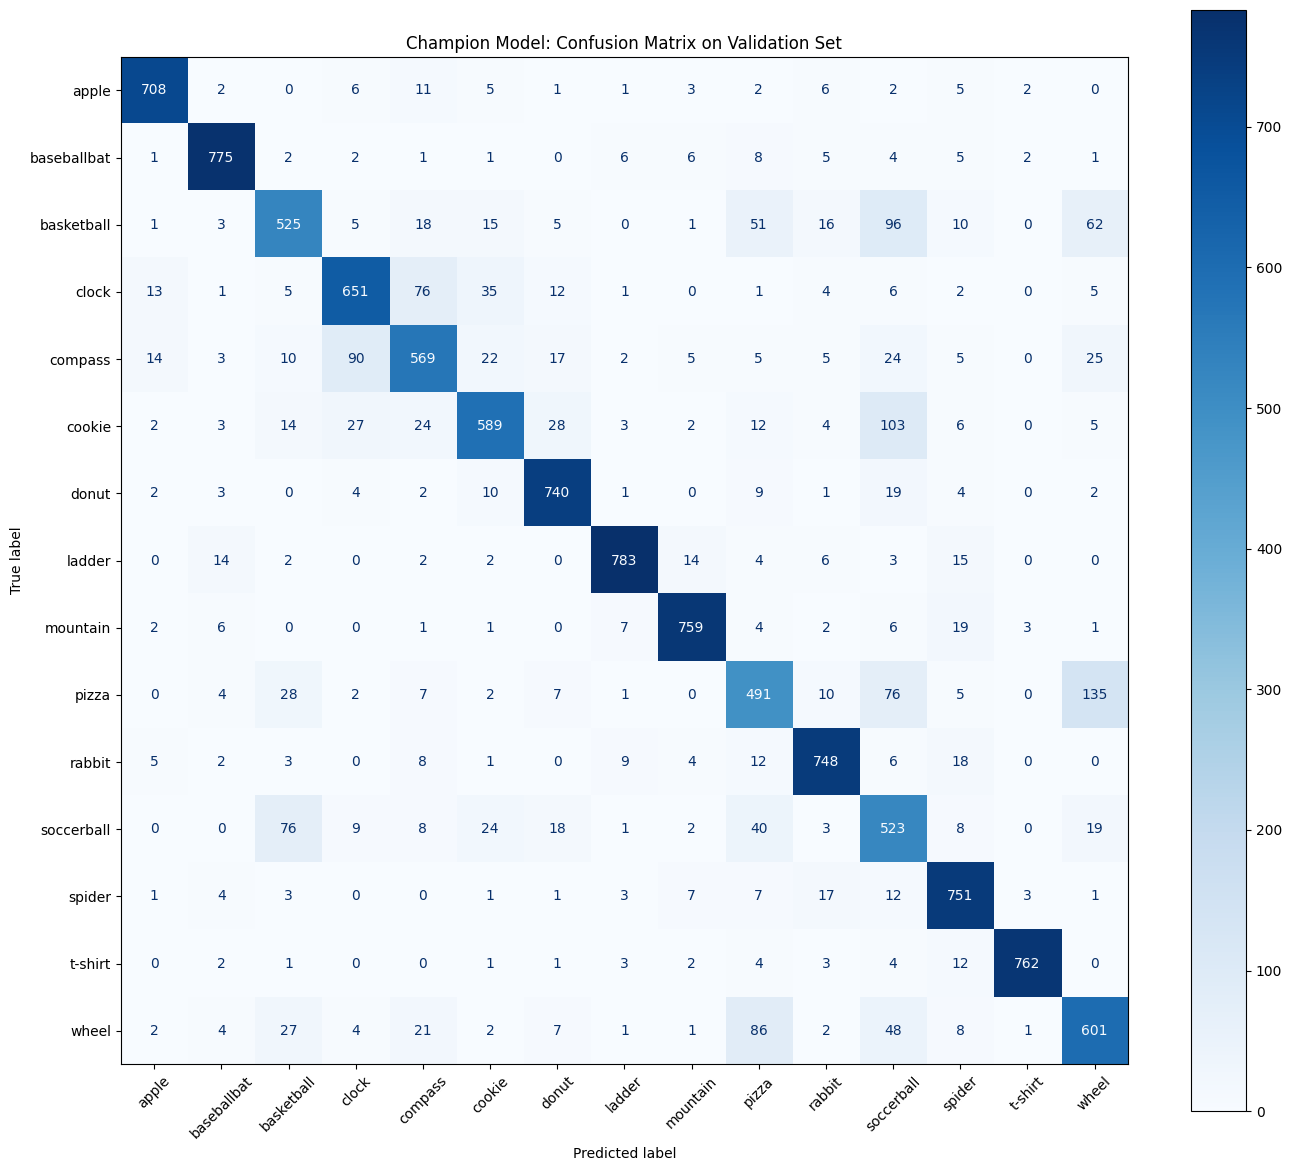


Top 2 Most Confused Class Pairs:
  1. 'pizza' vs 'wheel' — 221 total misclassifications
  2. 'basketball' vs 'soccerball' — 172 total misclassifications


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

model.load_state_dict(torch.load('champion_best.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title('Champion Model: Confusion Matrix on Validation Set')
plt.tight_layout()
plt.show()

np.fill_diagonal(cm, 0)
top_pairs = []
cm_copy = cm + cm.T
np.fill_diagonal(cm_copy, 0)
for _ in range(2):
    idx = np.unravel_index(np.argmax(cm_copy), cm_copy.shape)
    top_pairs.append((idx[0], idx[1], cm_copy[idx[0], idx[1]]))
    cm_copy[idx[0], idx[1]] = 0
    cm_copy[idx[1], idx[0]] = 0

print("\nTop 2 Most Confused Class Pairs:")
for i, (c1, c2, count) in enumerate(top_pairs):
    print(f"  {i+1}. '{class_names[c1]}' vs '{class_names[c2]}' — {count} total misclassifications")

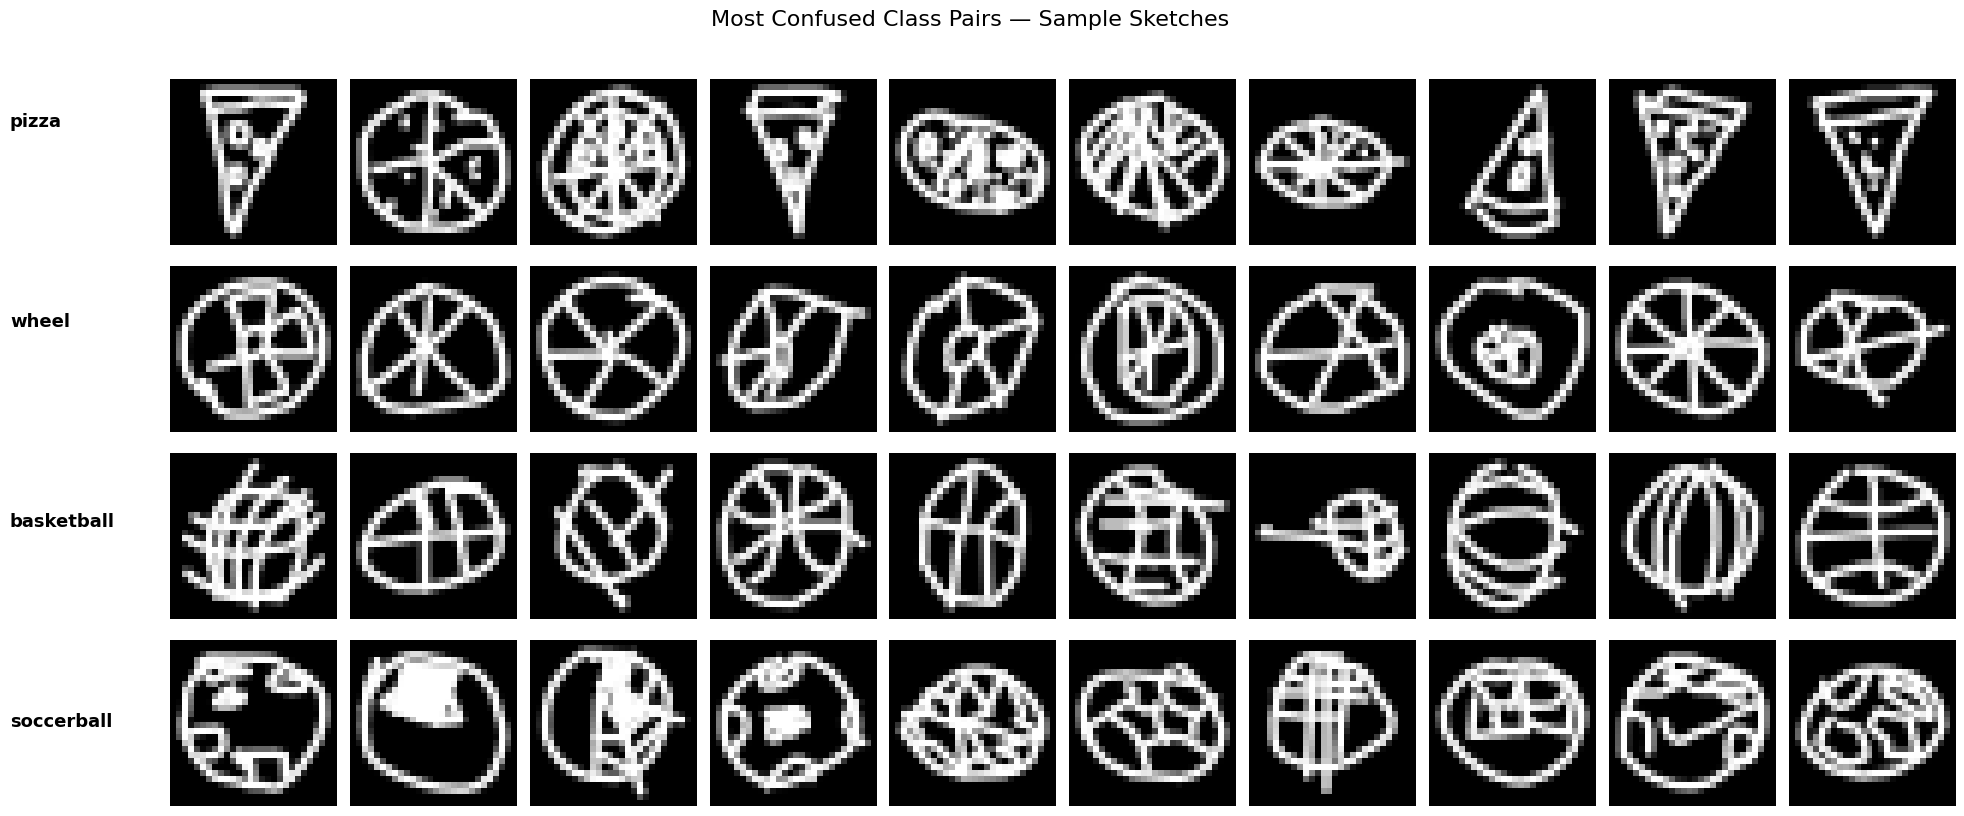

In [ ]:
fig, axes = plt.subplots(4, 10, figsize=(20, 8))

confused_pairs = [('pizza', 'wheel'), ('basketball', 'soccerball')]

for row_offset, (cls_a, cls_b) in enumerate(confused_pairs):
    idx_a = list(class_names).index(cls_a)
    idx_b = list(class_names).index(cls_b)

    samples_a = X_train[y_train == idx_a][:10]
    samples_b = X_train[y_train == idx_b][:10]

    for col in range(10):
        axes[row_offset * 2, col].imshow(samples_a[col].reshape(28, 28), cmap='gray')
        axes[row_offset * 2, col].axis('off')
        if col == 0:
            axes[row_offset * 2, col].set_ylabel(cls_a, fontsize=12, rotation=0, labelpad=60)

        axes[row_offset * 2 + 1, col].imshow(samples_b[col].reshape(28, 28), cmap='gray')
        axes[row_offset * 2 + 1, col].axis('off')
        if col == 0:
            axes[row_offset * 2 + 1, col].set_ylabel(cls_b, fontsize=12, rotation=0, labelpad=60)

for row_offset, (cls_a, cls_b) in enumerate(confused_pairs):
    fig.text(0.02, 0.88 - row_offset * 0.5, cls_a, fontsize=13, fontweight='bold', va='center')
    fig.text(0.02, 0.63 - row_offset * 0.5, cls_b, fontsize=13, fontweight='bold', va='center')

fig.suptitle('Most Confused Class Pairs — Sample Sketches', fontsize=16, y=1.02)
plt.tight_layout()
plt.subplots_adjust(left=0.1)
plt.show()

MODEL COMPARISON TABLE (Part E)
             Model  Hidden Layers   Architecture Parameters Activation  Epochs Best Val Acc (%)
    Pancake (Wide)              2       1024→512  1,339,407       ReLU      40            82.83
      Tower (Deep)             10         128×10    253,583       GELU      40            75.63
Champion (Tapered)              4 512→256→128→64    577,295       GELU      40            83.12


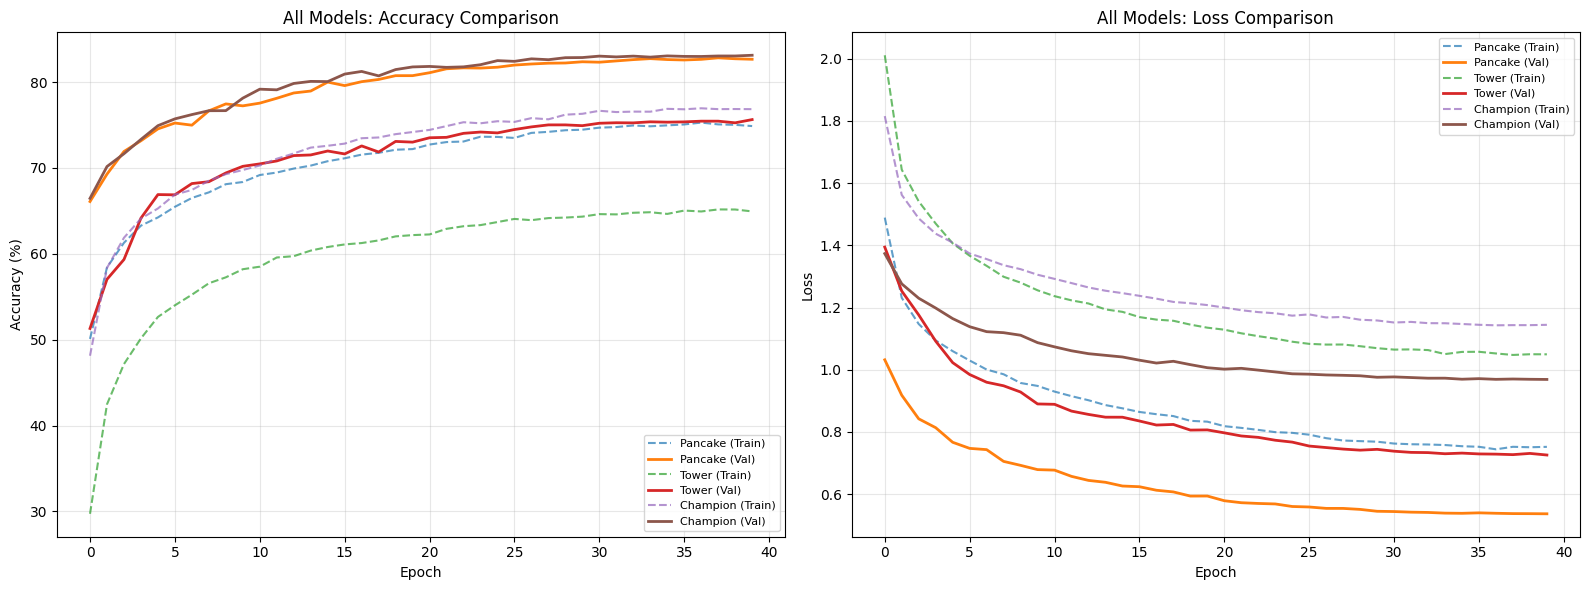

In [ ]:
import pandas as pd

params_pancake = sum(p.numel() for p in model_pancake.parameters())
params_tower = sum(p.numel() for p in model_tower.parameters())
params_champion = sum(p.numel() for p in model.parameters())

comparison = pd.DataFrame({
    'Model': ['Pancake (Wide)', 'Tower (Deep)', 'Champion (Tapered)'],
    'Hidden Layers': [2, 10, 4],
    'Architecture': ['1024→512', '128×10', '512→256→128→64'],
    'Parameters': [f'{params_pancake:,}', f'{params_tower:,}', f'{params_champion:,}'],
    'Activation': ['ReLU', 'GELU', 'GELU'],
    'Epochs': [40, 40, 40],
    'Best Val Acc (%)': [
        f"{max(history_a['val_accs']):.2f}",
        f"{max(history_b['val_accs']):.2f}",
        f"{max(history_c['val_accs']):.2f}"
    ]
})
print("=" * 80)
print("MODEL COMPARISON TABLE (Part E)")
print("=" * 80)
print(comparison.to_string(index=False))
print("=" * 80)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(history_a['train_accs'], label='Pancake (Train)', linestyle='--', alpha=0.7)
ax1.plot(history_a['val_accs'], label='Pancake (Val)', linewidth=2)
ax1.plot(history_b['train_accs'], label='Tower (Train)', linestyle='--', alpha=0.7)
ax1.plot(history_b['val_accs'], label='Tower (Val)', linewidth=2)
ax1.plot(history_c['train_accs'], label='Champion (Train)', linestyle='--', alpha=0.7)
ax1.plot(history_c['val_accs'], label='Champion (Val)', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('All Models: Accuracy Comparison')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.plot(history_a['train_losses'], label='Pancake (Train)', linestyle='--', alpha=0.7)
ax2.plot(history_a['val_losses'], label='Pancake (Val)', linewidth=2)
ax2.plot(history_b['train_losses'], label='Tower (Train)', linestyle='--', alpha=0.7)
ax2.plot(history_b['val_losses'], label='Tower (Val)', linewidth=2)
ax2.plot(history_c['train_losses'], label='Champion (Train)', linestyle='--', alpha=0.7)
ax2.plot(history_c['val_losses'], label='Champion (Val)', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('All Models: Loss Comparison')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()